# Introducción teórica

En esta practica se estudia la estimación de los parámetros de una señal sinusoidal en presencia de ruido aleatorio. La señal analizada está dada por

$$
x(n)=a_0\sin(\Omega_1 n)+n_a(n)
$$

donde a0 es la amplitud de la sinusoidal,  Omega_1  su frecuencia angular discreta y  na(n)  es un ruido blanco gaussiano de media nula y varianza  sigma^2 .

La amplitud utilizada es

$$
a_0=\sqrt{2},
$$

por lo que la potencia de la componente sinusoidal es

$$
P_s=\frac{a_0^2}{2}=1\;W.
$$

La frecuencia de la sinusoidal no es exactamente igual a la frecuencia central  Omega_0 , sino que se introduce una desintonía aleatoria:

$$
\Omega_1=\Omega_0+f_r\frac{2\pi}{N},
$$

con

$$
\Omega_0=\frac{\pi}{2},
\qquad
f_r\sim U(-2,2).
$$

De esta manera, la frecuencia de la señal puede encontrarse hasta dos intervalos de frecuencia  Deltaf = fs /N  por encima o por debajo de Omega_0. Para fs=1000 Hz y N=1000 muestras se obtiene

$$
\Delta f=\frac{f_s}{N}=1\;Hz,
$$

 

## Relación señal-ruido

La relación señal-ruido (SNR) se define como

$$
SNR=\frac{P_s}{P_n},
$$

o, expresada en decibelios,

$$
SNR_{dB}=10\log_{10}\left(\frac{P_s}{P_n}\right).
$$

Como Ps=1 W, la potencia del ruido utilizada en cada experimento es

$$
\sigma^2=P_n=\frac{1}{10^{SNR_{dB}/10}}.
$$

Por lo tanto, para  SNR=3  dB se obtiene sigma^2 approx0.5012 , mientras que para  SNR=10 dB se obtiene  sigma^2=0.1

## Análisis espectral y ventanas

Para estimar la amplitud y la frecuencia de la sinusoidal se analiza su transformada de Fourier después de aplicar diferentes ventanas temporales. Si \(w_i(n)\) representa una ventana, la señal ventaneada es

$$
x_w(n)=x(n)w_i(n)
$$

y su transformada de Fourier puede escribirse como

$$
X_{iw}(\Omega)=\mathcal{F}\{x(n)w_i(n)\}.
$$

El uso de una ventana modifica la forma del espectro. En particular, existe un compromiso entre el ancho del lóbulo principal y la atenuación de los lóbulos laterales. Por este motivo, distintas ventanas pueden producir diferentes resultados en la estimación de amplitud y frecuencia.

se comparan cuatro ventanas:

* **Rectangular**, que equivale a no aplicar una ventana.
* **Flat-top**, diseñada para obtener una elevada precisión en la estimación de amplitud.
* **Blackman-Harris**, que presenta una fuerte reducción de los lóbulos laterales.
* **Hann**, que proporciona un compromiso entre resolución espectral y reducción del leakage.

Para estimar la amplitud  a_0 , se toma el valor del bin  =250  (\(N/4\)) de la DFT para cada una de las 200 realizaciones. Este bin corresponde a una frecuencia de  250  Hz , por lo que se obtienen 200 valores estimados de amplitud.

Para estimar la frecuencia, se busca el bin de la DFT que presenta el mayor módulo para cada una de las 200 realizaciones. Luego, a partir del número de bin obtenido y de la resolución en frecuencia (Delta f = fs/N), se determina la frecuencia correspondiente.



## Sesgo y varianza

Para evaluar la calidad de los estimadores se realizan \(200\) experimentos independientes para cada nivel de SNR y para cada ventana.

El **sesgo** de un estimador indica cuánto se aleja, en promedio, la estimación del valor verdadero. Para la amplitud se calcula como

$$
\operatorname{Sesgo}(\hat a)
=
\overline{\hat a}-a_0.
$$

La **varianza** mide la dispersión de las estimaciones alrededor de su valor medio:

$$
\operatorname{Var}(\hat a)
=
\frac{1}{M}
\sum_{j=1}^{M}
(\hat a_j-\overline{\hat a})^2,
$$

donde  M=200  es el número de realizaciones.

 

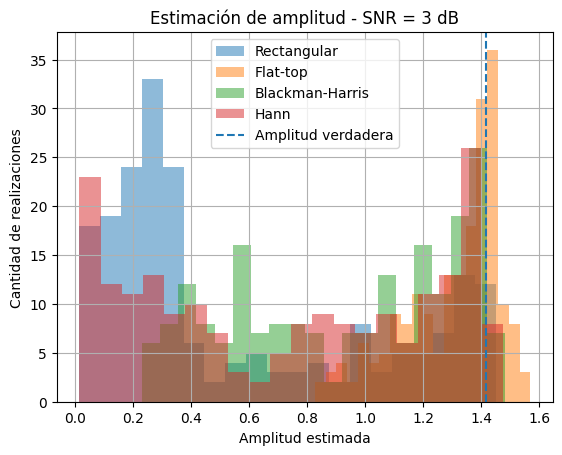

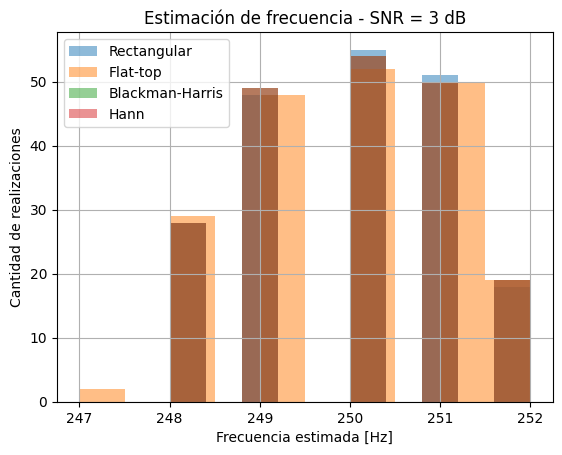

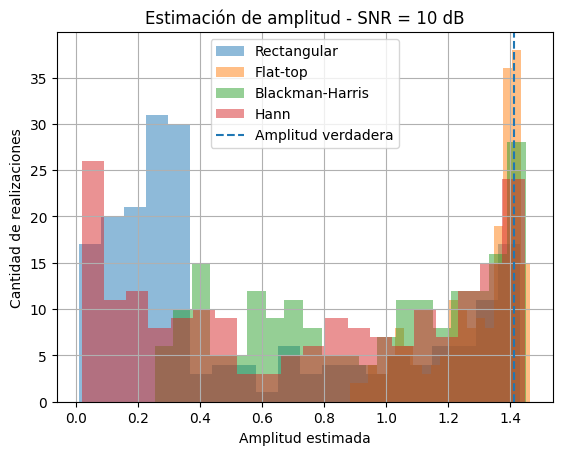

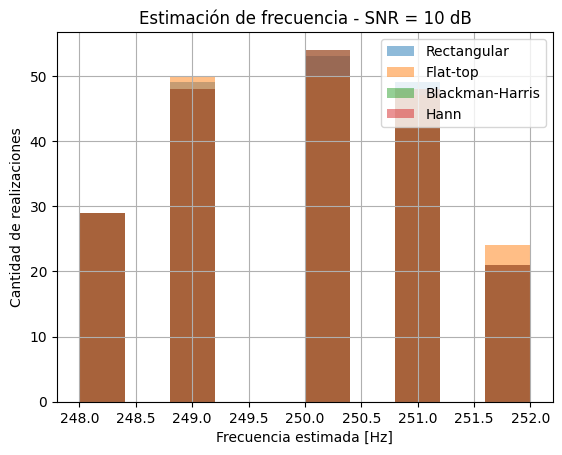

In [11]:
# -*- coding: utf-8 -*-

#%% IMPORTACION DE MODULOS

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig


#%% PARAMETROS

N = 1000
M = 200
fs = 1000

a0 = np.sqrt(2)

Omega0 = np.pi/2


#%% FRECUENCIAS

fr = np.random.uniform(-2, 2, M)
fr = fr.reshape((M, 1))

Omega1 = Omega0 + fr * 2*np.pi/N


#%% VECTOR DE MUESTRAS

n = np.arange(N)
n = n.reshape((1, N))


#%% VENTANAS

rect = np.ones(N)
flat = sig.windows.flattop(N)
bh = sig.windows.blackmanharris(N)
hann = sig.windows.hann(N)


#%% SNR = 3 dB

SNR = 3

Ps = a0**2/2
Pn = Ps/(10**(SNR/10))
sigma = np.sqrt(Pn)

ruido = np.random.normal(0, sigma, (M, N))

x = a0*np.sin(Omega1*n) + ruido


#%% RECTANGULAR

xw = x*rect

X = np.fft.fft(xw, axis=1)

#--------------------------Estimador de amplitud-------------------

amplitud_rect = 2*np.abs(X[:, N//4])/np.sum(rect)

#-------------------------Estimador de frecuencia-----------------

k_max_rect = np.argmax(np.abs(X[:, :N//2]), axis=1)
frecuencia_rect_3 = k_max_rect * fs / N


#%% FLAT-TOP

xw = x*flat

X = np.fft.fft(xw, axis=1)

#--------------------------Estimador de amplitud-------------------

amplitud_flat = 2*np.abs(X[:, N//4])/np.sum(flat)

#-------------------------Estimador de frecuencia-----------------

k_max_Flat = np.argmax(np.abs(X[:, :N//2]), axis=1)
frecuencia_Flat_3 = k_max_Flat * fs / N


#%% BLACKMAN-HARRIS

xw = x*bh

X = np.fft.fft(xw, axis=1)

#------------------------------Estimador de amplitud--------------

amplitud_bh = 2*np.abs(X[:, N//4])/np.sum(bh)

#-----------------------------Estimador de frecuencia-------------

k_max_Blackmann = np.argmax(np.abs(X[:, :N//2]), axis=1)
frecuencia_Black_3 = k_max_Blackmann * fs / N


#%% HANN

xw = x*hann

X = np.fft.fft(xw, axis=1)

#------------------------------Estimador de amplitud--------------

amplitud_hann = 2*np.abs(X[:, N//4])/np.sum(hann)

#-------------------------Estimador de frecuencia-----------------

k_max_Hann = np.argmax(np.abs(X[:, :N//2]), axis=1)
frecuencia_Hann_3 = k_max_Hann * fs / N


#%% HISTOGRAMA DE AMPLITUD - SNR = 3 dB

plt.figure()

plt.hist(amplitud_rect, bins=20, alpha=0.5, label="Rectangular")
plt.hist(amplitud_flat, bins=20, alpha=0.5, label="Flat-top")
plt.hist(amplitud_bh, bins=20, alpha=0.5, label="Blackman-Harris")
plt.hist(amplitud_hann, bins=20, alpha=0.5, label="Hann")

plt.axvline(a0, linestyle="--", label="Amplitud verdadera")

plt.xlabel("Amplitud estimada")
plt.ylabel("Cantidad de realizaciones")
plt.title("Estimación de amplitud - SNR = 3 dB")
plt.legend()
plt.grid()
plt.show()


#%% HISTOGRAMA DE FRECUENCIA - SNR = 3 dB

plt.figure()

plt.hist(frecuencia_rect_3, bins=10, alpha=0.5, label="Rectangular")
plt.hist(frecuencia_Flat_3, bins=10, alpha=0.5, label="Flat-top")
plt.hist(frecuencia_Black_3, bins=10, alpha=0.5, label="Blackman-Harris")
plt.hist(frecuencia_Hann_3, bins=10, alpha=0.5, label="Hann")

plt.xlabel("Frecuencia estimada [Hz]")
plt.ylabel("Cantidad de realizaciones")
plt.title("Estimación de frecuencia - SNR = 3 dB")
plt.legend()
plt.grid()
plt.show()


#%% SNR = 10 dB

SNR = 10

Ps = a0**2/2
Pn = Ps/(10**(SNR/10))
sigma = np.sqrt(Pn)

ruido = np.random.normal(0, sigma, (M, N))

x = a0*np.sin(Omega1*n) + ruido


#%% RECTANGULAR - 10 dB

xw = x*rect

X = np.fft.fft(xw, axis=1)

#--------------------------Estimador de amplitud-------------------

amplitud_rect = 2*np.abs(X[:, N//4])/np.sum(rect)

#-------------------------Estimador de frecuencia-----------------

k_max_rect = np.argmax(np.abs(X[:, :N//2]), axis=1)
frecuencia_rect = k_max_rect * fs / N


#%% FLAT-TOP - 10 dB

xw = x*flat

X = np.fft.fft(xw, axis=1)

#--------------------------Estimador de amplitud-------------------

amplitud_flat = 2*np.abs(X[:, N//4])/np.sum(flat)

#-------------------------Estimador de frecuencia-----------------

k_max_Flat = np.argmax(np.abs(X[:, :N//2]), axis=1)
frecuencia_Flat = k_max_Flat * fs / N


#%% BLACKMAN-HARRIS - 10 dB

xw = x*bh

X = np.fft.fft(xw, axis=1)

#------------------------------Estimador de amplitud--------------

amplitud_bh = 2*np.abs(X[:, N//4])/np.sum(bh)

#-----------------------------Estimador de frecuencia-------------

k_max_Blackmann = np.argmax(np.abs(X[:, :N//2]), axis=1)
frecuencia_Black = k_max_Blackmann * fs / N


#%% HANN - 10 dB

xw = x*hann

X = np.fft.fft(xw, axis=1)

#------------------------------Estimador de amplitud--------------

amplitud_hann = 2*np.abs(X[:, N//4])/np.sum(hann)

#-------------------------Estimador de frecuencia-----------------

k_max_Hann = np.argmax(np.abs(X[:, :N//2]), axis=1)
frecuencia_Hann = k_max_Hann * fs / N


#%% HISTOGRAMA DE AMPLITUD - SNR = 10 dB

plt.figure()

plt.hist(amplitud_rect, bins=20, alpha=0.5, label="Rectangular")
plt.hist(amplitud_flat, bins=20, alpha=0.5, label="Flat-top")
plt.hist(amplitud_bh, bins=20, alpha=0.5, label="Blackman-Harris")
plt.hist(amplitud_hann, bins=20, alpha=0.5, label="Hann")

plt.axvline(a0, linestyle="--", label="Amplitud verdadera")

plt.xlabel("Amplitud estimada")
plt.ylabel("Cantidad de realizaciones")
plt.title("Estimación de amplitud - SNR = 10 dB")
plt.legend()
plt.grid()
plt.show()


#%% HISTOGRAMA DE FRECUENCIA - SNR = 10 dB

plt.figure()

plt.hist(frecuencia_rect, bins=10, alpha=0.5, label="Rectangular")
plt.hist(frecuencia_Flat, bins=10, alpha=0.5, label="Flat-top")
plt.hist(frecuencia_Black, bins=10, alpha=0.5, label="Blackman-Harris")
plt.hist(frecuencia_Hann, bins=10, alpha=0.5, label="Hann")

plt.xlabel("Frecuencia estimada [Hz]")
plt.ylabel("Cantidad de realizaciones")
plt.title("Estimación de frecuencia - SNR = 10 dB")
plt.legend()
plt.grid()
plt.show()

 

Para un SNR de 3 dB, las estimaciones de amplitud presentan una mayor dispersión debido al mayor nivel de ruido.  

Para un SNR de 10 dB, las distribuciones presentan menor dispersión que para 3 dB, ya que el nivel de ruido es menor. Se observa también que las estimaciones se encuentran, en general, más concentradas alrededor de determinados valores.

La diferencia entre las ventanas se debe a que cada una modifica de manera diferente el espectro de la señal, afectando la estimación de amplitud.


# Visualización de las cuatro ventanas

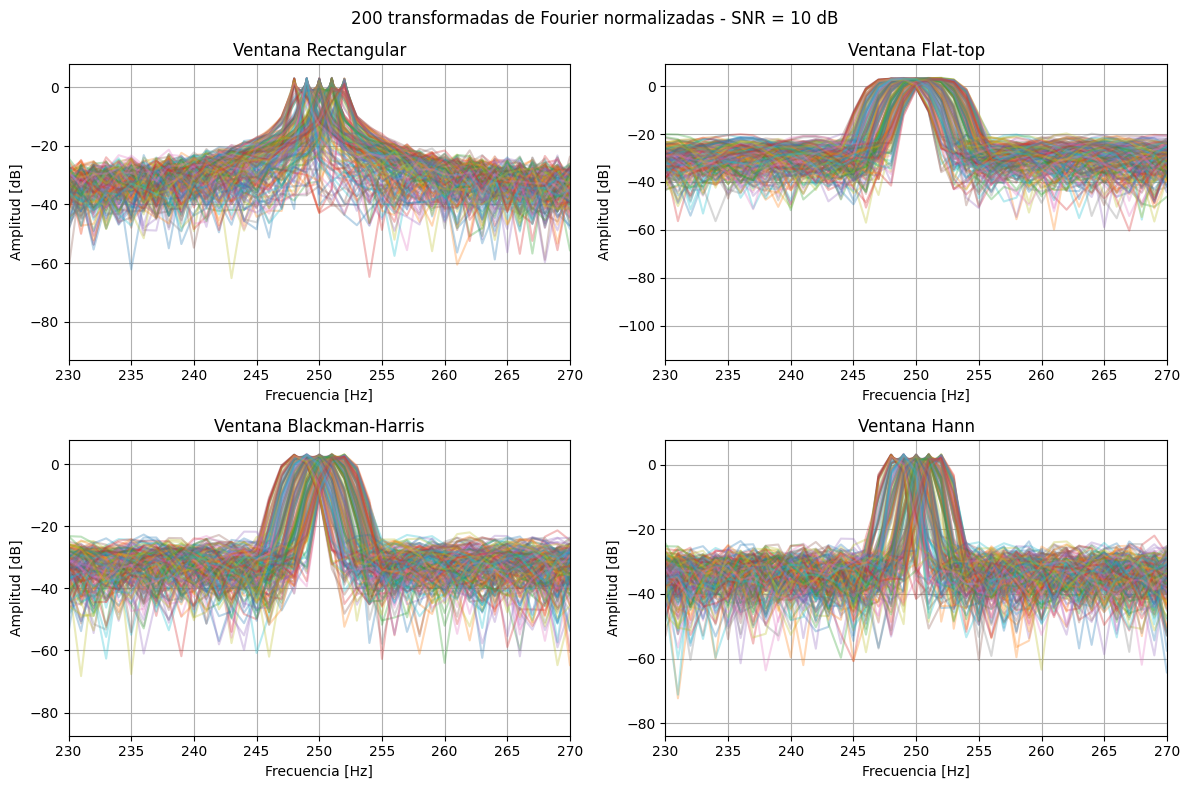

In [10]:
#%% TRANSFORMADAS DE FOURIER NORMALIZADAS EN dB - 200 REALIZACIONES

# Aplicamos cada ventana
x_rect = x * rect
x_flat = x * flat
x_bh = x * bh
x_hann = x * hann

# FFT de las 200 realizaciones
X_rect = np.fft.fft(x_rect, axis=1)
X_flat = np.fft.fft(x_flat, axis=1)
X_bh = np.fft.fft(x_bh, axis=1)
X_hann = np.fft.fft(x_hann, axis=1)

# Vector de frecuencias
f = np.fft.fftfreq(N, 1/fs)

# Solo frecuencias positivas
idx = f >= 0


#%% NORMALIZACION DE AMPLITUD

amplitud_fft_rect = 2 * np.abs(X_rect) / np.sum(rect)
amplitud_fft_flat = 2 * np.abs(X_flat) / np.sum(flat)
amplitud_fft_bh = 2 * np.abs(X_bh) / np.sum(bh)
amplitud_fft_hann = 2 * np.abs(X_hann) / np.sum(hann)


#%% PASAJE A dB

amplitud_fft_rect_db = 20 * np.log10(amplitud_fft_rect + 1e-12)
amplitud_fft_flat_db = 20 * np.log10(amplitud_fft_flat + 1e-12)
amplitud_fft_bh_db = 20 * np.log10(amplitud_fft_bh + 1e-12)
amplitud_fft_hann_db = 20 * np.log10(amplitud_fft_hann + 1e-12)


#%% GRAFICO

fig, axs = plt.subplots(2, 2, figsize=(12, 8))


# RECTANGULAR
for i in range(M):
    axs[0, 0].plot(
        f[idx],
        amplitud_fft_rect_db[i, idx],
        alpha=0.3
    )

axs[0, 0].set_title("Ventana Rectangular")
axs[0, 0].set_xlim(230, 270)
axs[0, 0].set_xlabel("Frecuencia [Hz]")
axs[0, 0].set_ylabel("Amplitud [dB]")
axs[0, 0].grid()


# FLAT-TOP
for i in range(M):
    axs[0, 1].plot(
        f[idx],
        amplitud_fft_flat_db[i, idx],
        alpha=0.3
    )

axs[0, 1].set_title("Ventana Flat-top")
axs[0, 1].set_xlim(230, 270)
axs[0, 1].set_xlabel("Frecuencia [Hz]")
axs[0, 1].set_ylabel("Amplitud [dB]")
axs[0, 1].grid()


# BLACKMAN-HARRIS
for i in range(M):
    axs[1, 0].plot(
        f[idx],
        amplitud_fft_bh_db[i, idx],
        alpha=0.3
    )

axs[1, 0].set_title("Ventana Blackman-Harris")
axs[1, 0].set_xlim(230, 270)
axs[1, 0].set_xlabel("Frecuencia [Hz]")
axs[1, 0].set_ylabel("Amplitud [dB]")
axs[1, 0].grid()


# HANN
for i in range(M):
    axs[1, 1].plot(
        f[idx],
        amplitud_fft_hann_db[i, idx],
        alpha=0.3
    )

axs[1, 1].set_title("Ventana Hann")
axs[1, 1].set_xlim(230, 270)
axs[1, 1].set_xlabel("Frecuencia [Hz]")
axs[1, 1].set_ylabel("Amplitud [dB]")
axs[1, 1].grid()


plt.suptitle("200 transformadas de Fourier normalizadas - SNR = 10 dB")
plt.tight_layout()
plt.show()

El estimador de amplitud evalúa |Xw| en una frecuencia **fija**  250 Hz , mientras que la frecuencia de cada realización varía en 250 ± 2 Hz. 

Rectangular: tiene el lóbulo principal más angosto, pero sus lóbulos laterales son altos y decaen lentamente. Esto se observa con forma de "triangulo"  que sobresalen del piso de ruido a varios Hz del pico. Esta ventana desparama mucho la energia

Flat-top y Blackman-Harris: tienen lóbulos laterales muy bajos y caen rápido. A cambio, ensanchan el lóbulo principal, es decir, pierden resolución espectral, por esto la energía de la senoidal queda confinada a una región central.


# Amplitud

In [4]:
#%% SESGO Y VARIANZA - AMPLITUD - SNR = 10 dB

sesgo_rect = np.mean(amplitud_rect - a0)
varianza_rect = np.var(amplitud_rect - a0)

sesgo_flat = np.mean(amplitud_flat - a0)
varianza_flat = np.var(amplitud_flat - a0)

sesgo_bh = np.mean(amplitud_bh - a0)
varianza_bh = np.var(amplitud_bh - a0)

sesgo_hann = np.mean(amplitud_hann - a0)
varianza_hann = np.var(amplitud_hann - a0)

print("SNR = 10 dB")
print()
print(f"{'Ventana':<18} {'Sesgo':>12} {'Varianza':>12}")
print("-" * 44)
print(f"{'Rectangular':<18} {sesgo_rect:>12.4f} {varianza_rect:>12.4f}")
print(f"{'Flat-top':<18} {sesgo_flat:>12.4f} {varianza_flat:>12.4f}")
print(f"{'Blackman-Harris':<18} {sesgo_bh:>12.4f} {varianza_bh:>12.4f}")
print(f"{'Hann':<18} {sesgo_hann:>12.4f} {varianza_hann:>12.4f}")

SNR = 10 dB

Ventana                   Sesgo     Varianza
--------------------------------------------
Rectangular             -0.9460       0.1915
Flat-top                -0.1306       0.0244
Blackman-Harris         -0.5178       0.1356
Hann                    -0.7355       0.2273


Para un SNR de 10 dB, las cuatro ventanas presentan un sesgo negativo, por lo que tienden a subestimar la amplitud. La ventana Flat-top presenta el sesgo más cercano a cero y la menor varianza, mientras que Hann presenta la mayor varianza.


# Frecuencia

In [5]:
#%% SESGO Y VARIANZA - FRECUENCIA - SNR = 10 dB

f_real = 250 + fr[:, 0]

sesgo_rect = np.mean(frecuencia_rect - f_real)
varianza_rect = np.var(frecuencia_rect - f_real)

sesgo_flat = np.mean(frecuencia_Flat - f_real)
varianza_flat = np.var(frecuencia_Flat - f_real)

sesgo_bh = np.mean(frecuencia_Black - f_real)
varianza_bh = np.var(frecuencia_Black - f_real)

sesgo_hann = np.mean(frecuencia_Hann - f_real)
varianza_hann = np.var(frecuencia_Hann - f_real)

print("SNR = 10 dB")
print()
print(f"{'Ventana':<18} {'Sesgo':>12} {'Varianza':>12}")
print("-" * 44)
print(f"{'Rectangular':<18} {sesgo_rect:>12.4f} {varianza_rect:>12.4f}")
print(f"{'Flat-top':<18} {sesgo_flat:>12.4f} {varianza_flat:>12.4f}")
print(f"{'Blackman-Harris':<18} {sesgo_bh:>12.4f} {varianza_bh:>12.4f}")
print(f"{'Hann':<18} {sesgo_hann:>12.4f} {varianza_hann:>12.4f}")

SNR = 10 dB

Ventana                   Sesgo     Varianza
--------------------------------------------
Rectangular              0.0072       0.0834
Flat-top                 0.0372       0.1155
Blackman-Harris          0.0222       0.0833
Hann                     0.0172       0.0833


In [6]:
#%% SESGO Y VARIANZA - FRECUENCIA - SNR = 3 dB

f_real = 250 + fr[:, 0]

sesgo_rect_3 = np.mean(frecuencia_rect_3 - f_real)
varianza_rect_3 = np.var(frecuencia_rect_3 - f_real)

sesgo_flat_3 = np.mean(frecuencia_Flat_3 - f_real)
varianza_flat_3 = np.var(frecuencia_Flat_3 - f_real)

sesgo_bh_3 = np.mean(frecuencia_Black_3 - f_real)
varianza_bh_3 = np.var(frecuencia_Black_3 - f_real)

sesgo_hann_3 = np.mean(frecuencia_Hann_3 - f_real)
varianza_hann_3 = np.var(frecuencia_Hann_3 - f_real)

print("SNR = 3 dB")
print()
print(f"{'Ventana':<18} {'Sesgo':>12} {'Varianza':>12}")
print("-" * 44)
print(f"{'Rectangular':<18} {sesgo_rect_3:>12.4f} {varianza_rect_3:>12.4f}")
print(f"{'Flat-top':<18} {sesgo_flat_3:>12.4f} {varianza_flat_3:>12.4f}")
print(f"{'Blackman-Harris':<18} {sesgo_bh_3:>12.4f} {varianza_bh_3:>12.4f}")
print(f"{'Hann':<18} {sesgo_hann_3:>12.4f} {varianza_hann_3:>12.4f}")

SNR = 3 dB

Ventana                   Sesgo     Varianza
--------------------------------------------
Rectangular              0.0072       0.0836
Flat-top                -0.0128       0.1608
Blackman-Harris          0.0222       0.0843
Hann                     0.0122       0.0837


# CONCLUSIÓN

En conclusión, al aumentar el SNR de 3 dB a 10 dB, las estimaciones de amplitud presentan una menor dispersión debido a la reducción del ruido. Además, las diferencias observadas entre las ventanas muestran que la elección de la ventana influye en la precisión de la estimación.

Para la estimación de **amplitud**, la ventana **Flat-top** presenta el menor sesgo y la menor varianza, por lo que resulta la más precisa entre las ventanas. Para la estimación de **frecuencia** la misma ventana Flat-top presenta una mayor varianza que las restantes, especialmente para un SNR de 3 dB. 
